In [143]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [144]:
df = pd.read_csv('Student_performance_data.csv')

In [145]:
df.tail()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
2387,3388,18,1,0,3,10.680555,2,0,4,1,0,0,0,3.455509,0.0
2388,3389,17,0,0,1,7.583217,4,1,4,0,1,0,0,3.279150,4.0
2389,3390,16,1,0,2,6.805500,20,0,2,0,0,0,1,1.142333,2.0
2390,3391,16,1,1,0,12.416653,17,0,2,0,1,1,0,1.803297,1.0
2391,3392,16,1,0,2,17.819907,13,0,2,0,0,0,1,2.140014,1.0


In [146]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 280.4 KB


In [147]:
df.groupby('GPA').count()
# Too many GPAs. I got to condense/round them

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GradeClass
GPA,,,,,,,,,,,,,,
0.000000,16,16,16,16,16,16,16,16,16,16,16,16,16,16
0.012063,1,1,1,1,1,1,1,1,1,1,1,1,1,1
0.019798,1,1,1,1,1,1,1,1,1,1,1,1,1,1
0.021156,1,1,1,1,1,1,1,1,1,1,1,1,1,1
0.026469,1,1,1,1,1,1,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3.947093,1,1,1,1,1,1,1,1,1,1,1,1,1,1
3.951460,1,1,1,1,1,1,1,1,1,1,1,1,1,1
3.979421,1,1,1,1,1,1,1,1,1,1,1,1,1,1


In [148]:
# Round the GPAs to the nearest 0.01
def round_gpa(gpa):
    return round(gpa, 2)

df['GPA'] = df['GPA'].apply(round_gpa)

In [149]:
df.groupby('GPA').count()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GradeClass
GPA,,,,,,,,,,,,,,
0.00,16,16,16,16,16,16,16,16,16,16,16,16,16,16
0.01,1,1,1,1,1,1,1,1,1,1,1,1,1,1
0.02,2,2,2,2,2,2,2,2,2,2,2,2,2,2
0.03,2,2,2,2,2,2,2,2,2,2,2,2,2,2
0.08,1,1,1,1,1,1,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3.88,1,1,1,1,1,1,1,1,1,1,1,1,1,1
3.94,1,1,1,1,1,1,1,1,1,1,1,1,1,1
3.95,2,2,2,2,2,2,2,2,2,2,2,2,2,2


In [150]:
df['GradeClass'].value_counts(normalize=True)

GradeClass
4.0    0.506271
3.0    0.173077
2.0    0.163462
1.0    0.112458
0.0    0.044732
Name: proportion, dtype: float64

In [151]:
#switch values of GradeClass as it is a little confusing
df['newGradeClass'] = 4 - df['GradeClass']

In [152]:
df['newGradeClass'].value_counts(normalize=True)

newGradeClass
0.0    0.506271
1.0    0.173077
2.0    0.163462
3.0    0.112458
4.0    0.044732
Name: proportion, dtype: float64

In [153]:
df.groupby('Gender')['GPA'].mean() #0 Male, 1 Female

Gender
0    1.918735
1    1.894124
Name: GPA, dtype: float64

In [154]:
df.groupby('Tutoring')['GPA'].mean() #0 No, 1 Yes

Tutoring
0    1.818941
1    2.108308
Name: GPA, dtype: float64

In [155]:
df.groupby('ParentalSupport')['GPA'].mean() # 0 - Little to 5 - Very High

ParentalSupport
0    1.540094
1    1.755542
2    1.884257
3    2.042410
4    2.191614
Name: GPA, dtype: float64

In [156]:
df.groupby('Age')['GPA'].mean() # meh

Age
15    1.898524
16    1.907470
17    1.926968
18    1.892113
Name: GPA, dtype: float64

In [157]:
df.groupby('ParentalEducation')['GPA'].mean() # meh

ParentalEducation
0    1.893128
1    1.943777
2    1.929957
3    1.809019
4    1.816250
Name: GPA, dtype: float64

In [158]:
df.groupby('Absences')['GPA'].mean() # meh

Absences
0     3.401493
1     3.254471
2     3.082609
3     3.091646
4     2.971739
5     2.801566
6     2.758295
7     2.618488
8     2.516374
9     2.525970
10    2.440328
11    2.189296
12    2.129783
13    2.048710
14    2.069167
15    1.907241
16    1.770253
17    1.673827
18    1.565823
19    1.401333
20    1.389222
21    1.270482
22    1.123803
23    1.024302
24    0.945556
25    0.855591
26    0.720000
27    0.659881
28    0.536481
29    0.609565
Name: GPA, dtype: float64

In [159]:
df.groupby('StudyTimeWeekly')['GPA'].mean() # meh

StudyTimeWeekly
0.001057     2.97
0.004859     1.20
0.008031     0.00
0.008206     0.26
0.014337     1.38
             ... 
19.939810    2.24
19.948459    3.11
19.968425    0.91
19.972346    1.88
19.978094    1.55
Name: GPA, Length: 2392, dtype: float64

In [160]:
df.groupby('Sports')['GPA'].mean() # meh

Sports
0    1.871230
1    1.986322
Name: GPA, dtype: float64

In [161]:
df.groupby('Music')['GPA'].mean() # meh

Music
0    1.872998
1    2.041423
Name: GPA, dtype: float64

In [162]:
df.groupby('Volunteering')['GPA'].mean() # meh

Volunteering
0    1.904831
1    1.913298
Name: GPA, dtype: float64

In [163]:
df.groupby('Extracurricular')['GPA'].mean() # meh

Extracurricular
0    1.838244
1    2.015409
Name: GPA, dtype: float64

In [ ]:

from sklearn.model_selection import train_test_split


In [194]:
# splitting the data into training and testing sets
x = df[['Absences', 'ParentalSupport', 'Tutoring', 'Gender', 'StudyTimeWeekly', 'Music', 'Extracurricular']]
y = df['GPA']


x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.3, random_state=6)

In [174]:
import xgboost as xgb

In [196]:
model = xgb.XGBRegressor(n_estimators=1000, learning_rate=0.1, max_depth=3, random_state=6)
model.fit(x_train, y_train)

model.score(x_test, y_test)

0.9258196267559802

In [192]:
from xgboost import plot_importance

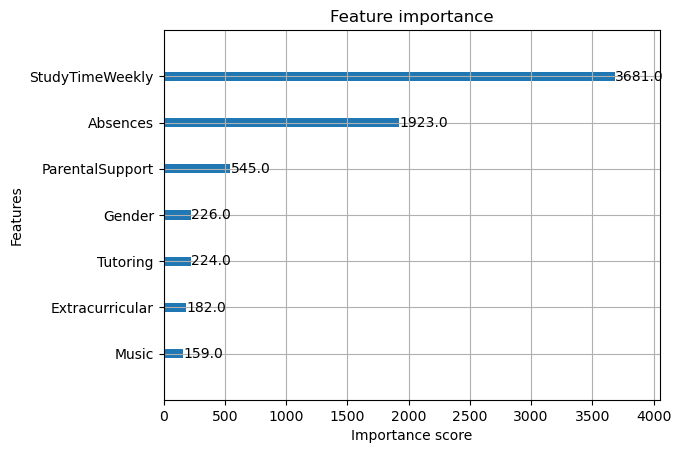

In [197]:
plot_importance(model)
plt.show()

In [198]:
# splitting the data into training and testing sets
x = df[['Absences', 'ParentalSupport', 'StudyTimeWeekly']]
y = df['GPA']


x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.3, random_state=6)

In [200]:
model = xgb.XGBRegressor()
model.fit(x_train, y_train)

model.score(x_test, y_test)

0.8796010371056743

In [ ]:
#import random tree regressor
from sklearn.ensemble import RandomForestRegressor

In [201]:
model = RandomForestRegressor(n_estimators=1000)
model.fit(x_train, y_train)

model.score(x_test, y_test)

0.8858755128714664